In [20]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))  # utils.* lives at repo root

from utils.io_utils import load

In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
SAMPLES_DIR = Path(r"D:\eturok\experiment-26\samples")

In [57]:
SAMPLE_ID = 8
LASER_IDX = None

In [58]:
def load_metadata(sample_dir):
    return {k: v for d in load(sample_dir / 'metadata.jsonl') for k, v in d.items()}

def scene_label(metadata):
    if metadata.get('is_empty_box'): return 'Empty Box'
    objects = metadata.get('objects', {})
    if not objects: return 'Empty Box'
    return ', '.join(name + (f' x{n}' if n > 1 else '') for name, n in objects.items())

In [ ]:
def plot_shifts(sample_id: int, laser_idx: int | None, samples_dir=SAMPLES_DIR):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    shifts = load(sample_dir / 'vibration/02_clean_shifts.npy')  # (1, L, T, 2)
    metadata = load_metadata(sample_dir)
    fps = int(metadata['fps'])  # shifts are sampled at the camera's fps, not a freq bin rate

    laser_shifts = shifts[0].mean(axis=0) if laser_idx is None else shifts[0, laser_idx]  # (T, 2)
    x_shifts = laser_shifts[:, 0]
    y_shifts = laser_shifts[:, 1]
    t = np.arange(len(x_shifts)) / fps  # frame index -> seconds

    laser_label = 'avg over lasers' if laser_idx is None else f'laser={laser_idx}'
    fig, axs = plt.subplots(2, 1, figsize=(16, 6))
    fig.suptitle(f"{scene_label(metadata)} Shifts {laser_label} speaker={metadata['speaker']}")

    axs[0].plot(t, x_shifts)
    axs[0].set_title('x shift')
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Shift (pixels)')

    axs[1].plot(t, y_shifts, color='orange')
    axs[1].set_title('y shift')
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Shift (pixels)')

    fig.tight_layout()
    return fig, axs

(<Figure size 1600x600 with 2 Axes>,
 array([<Axes: title={'center': 'x shift'}, xlabel='Time (s)', ylabel='Shift (pixels)'>,
        <Axes: title={'center': 'y shift'}, xlabel='Time (s)', ylabel='Shift (pixels)'>],
       dtype=object))

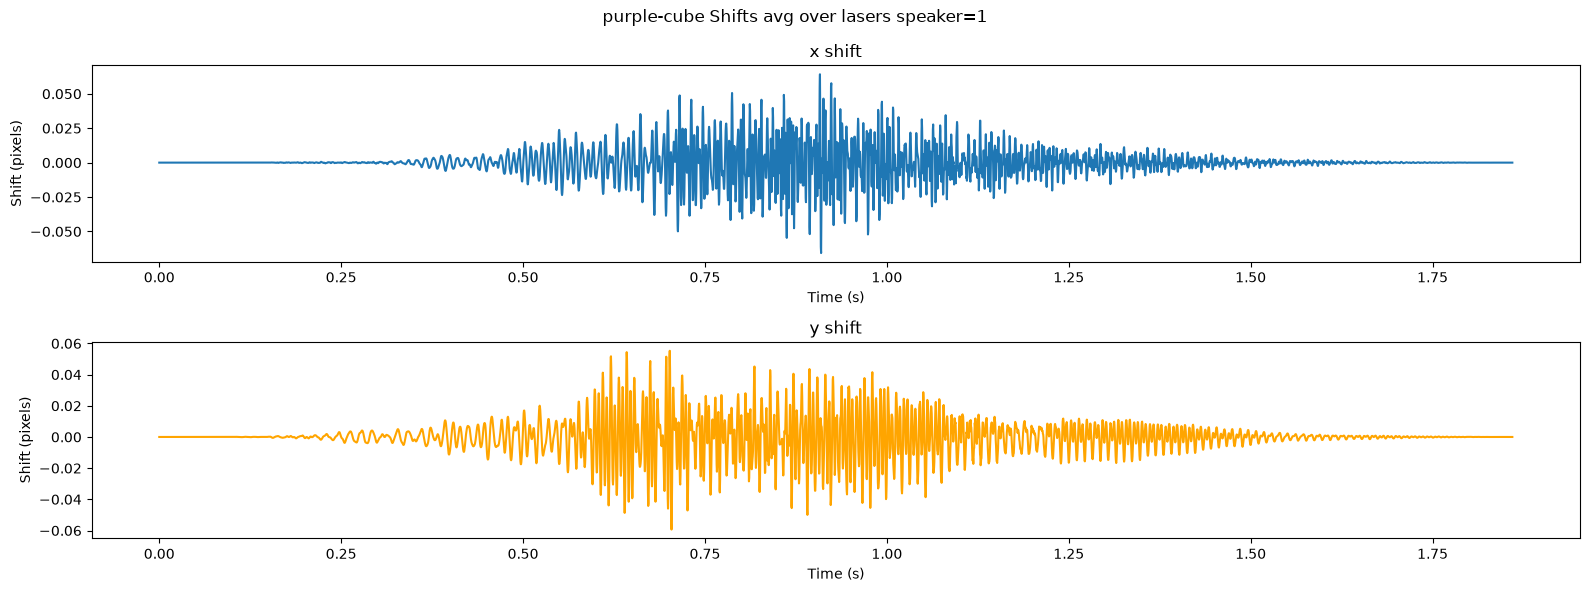

In [66]:
plot_shifts(SAMPLE_ID, LASER_IDX)

In [ ]:
def plot_fft_magnitude(sample_id: int, laser_idx: int | None, samples_dir=SAMPLES_DIR):
    sample_dir = Path(samples_dir) / f"{sample_id:06d}"
    fft, freqs = load(sample_dir / 'vibration/03_fft.npz', keys=['fft', 'freqs'])  # fft: (1, L, F, 2), freqs: (F,)
    metadata = load_metadata(sample_dir)

    mag = np.abs(fft[0])  # (L, F, 2)
    mag = mag.mean(axis=0) if laser_idx is None else mag[laser_idx]  # (F, 2)
    mag_x, mag_y = mag[:, 0], mag[:, 1]

    laser_label = 'avg over lasers' if laser_idx is None else f'laser={laser_idx}'
    fig, axs = plt.subplots(2, 1, figsize=(16, 6))
    fig.suptitle(f"{scene_label(metadata)} FFT Magnitude {laser_label} speaker={metadata['speaker']}")

    axs[0].plot(freqs, mag_x)
    axs[0].set_title('x shift')
    axs[0].set_xlabel('Frequency (Hz)')
    axs[0].set_ylabel('Magnitude')

    axs[1].plot(freqs, mag_y, color='orange')
    axs[1].set_title('y shift')
    axs[1].set_xlabel('Frequency (Hz)')
    axs[1].set_ylabel('Magnitude')

    fig.tight_layout()
    return fig, axs

(<Figure size 1600x600 with 2 Axes>,
 array([<Axes: title={'center': 'x shift'}, xlabel='Frequency (Hz)', ylabel='Magnitude'>,
        <Axes: title={'center': 'y shift'}, xlabel='Frequency (Hz)', ylabel='Magnitude'>],
       dtype=object))

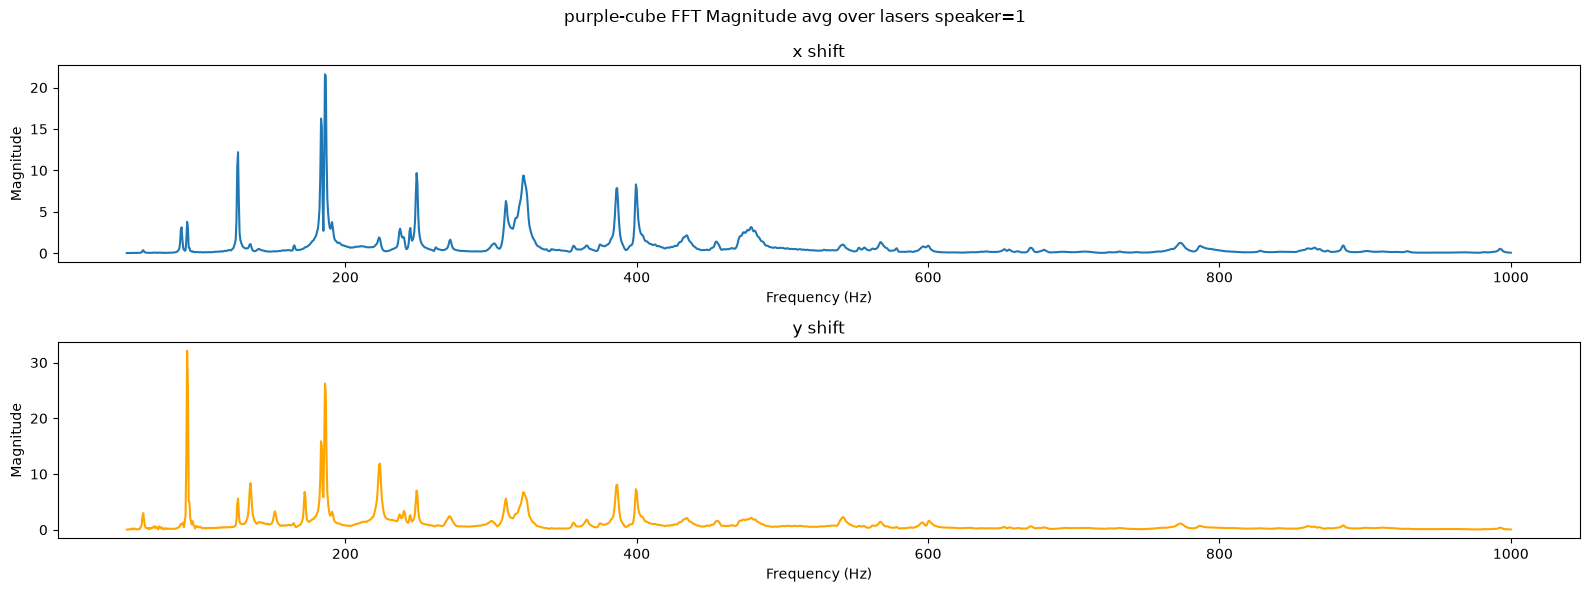

In [64]:
plot_fft_magnitude(SAMPLE_ID, LASER_IDX)